# Simulating Global Signal Data

The aim of this notebook is to introduce some of the features in `edges-analysis` that enable reasonably easy simulation of observed global signal spectra as a function of time and frequency. This will enable you also to produce some of your own data -- if you don't have data from your experiment yet -- that can then be used in the "BYOD" session (if you have time).


Note that we will be writing out the data in `.gsh5` format, so that in truth the BYOD notebook will be very very simple. Unfortunately, the simulation tools in `edges-analysis` are reasonably specific to EDGES-like data---they haven't been sufficiently generalized yet---so this will not be much of a test. 

However, you could also treat this as a reverse test---try using our simulation tools and augment them to produce data with similar characteristics to what you expect from your own instrument! And then try writing it into your own format (if you have one specified already).

### Required Imports

In [1]:
# External packages
import numpy as np
import matplotlib.pyplot as plt
import h5py
import scipy.io as sio

import astropy.time as apt
import astropy_healpix as ahp
import astropy.coordinates as apc
from astropy import units as un

# Basic pygsdata imports
from pygsdata import Telescope

# edges-analysis imports, specifically edges.sim
from edges.sim import beams, sky_models, simulate
from edges import modeling as mdl
from edges import const


## Set the location and reference time for the telescope

We are going to create time-frequency spectrum waterfalls as observed by a particular instrument.
The first thing we need to do is to specify the basic properties of the telescope itself -- its
location and orientation -- as well as defining a "reference time". What we'll end up doing is 
simulating the sky on a regular grid of LSTs, and the times corresponding to these LSTs will be 
as close as possible to this reference time.

In [2]:
telescope =Telescope(
    name="new_telescope",  # obviously could replace this with your telescope name
    location=apc.EarthLocation(
        lat=64 * un.deg,    # replace with your telescope's coordinates
        lon=116.5 * un.deg
    ),
    pols=("xx",),          # specify the feed-pairs measured by your telecope (EDGES just has one feed).
    integration_time=13.0 * un.s,   # the integration time--doesn't change ANYTHING about the ideal simulation, but could affect noise.
    x_orientation=0.0 * un.deg,  # Angle with respect to East at which the x-feed is pointing (y-feed is assumed to be 90deg rotated)
)

ref_time = apt.Time("2014-01-01T09:39:42", location=telescope.location)

## Define a beam

Next we need to specify the primary beam. There are a few ways to do this. We support passing in files in common formats from EM simulation tools, for example:

In [3]:
beams.Beam.from_cst  # read CST output files
beams.Beam.from_feko # read processed FEKO outputs
beams.Beam.from_feko_raw  # read raw FEKO outputs
beams.Beam.from_hfss # read HFSS outputs
beams.Beam.from_wipld; # read WIPL-D outputs

You could write your own beam reader as well -- all you need to do is construct a `Beam` object manually:

In [4]:
beams.Beam?

Init signature:
beams.Beam(
    *,
    beam: numpy.ndarray,
    frequency: Annotated[astropy.units.quantity.Quantity, PhysicalType('frequency')],
    elevation,
    azimuth,
    simulator=None,
    instrument=None,
    raw_file=None,
) -> None
Docstring:     
A beam model object.

Attributes
----------
beam
    The beam model, as a function of frequency, elevation, and azimuth.
frequency
    The frequencies at which the beam is defined.
elevation
    The elevation angles at which the beam is defined.
azimuth
    The azimuth angles at which the beam is defined.
simulator
    The simulator used to generate the beam.
instrument
    The instrument for which the beam is defined.
raw_file
    The path to the raw file from which the beam was read.
Init docstring: Method generated by attrs for class Beam.
File:           /data7/smurray/edges/workshop-notes/.venv/lib/python3.14/site-packages/edges/sim/beams.py
Type:           type
Subclasses:     

Note that currently only auto-pol beams are supported (i.e. real-valued primary beams). In the future, we will probably just interface with `pyuvdata.uvbeam` which supports much more complex scenarios. 

If you brought your own beam file, then go ahead and use one of the above methods! In case you didn't, you can also just use an analytic beam for now. Choose one of the following!

In [5]:
#beam = beams.Beam.uniform()
#beam = beams.Beam.gaussian(dish_size=4*un.m)
beam = beams.Beam.airy(dish_size=4)  # meters

## Define the LST range over which you want the simulated data

In [6]:
# This will generate a single integration every hour -- this is clearly quite coarse, just to make it fast.
lsts = apc.Longitude(np.arange(0, 24, 1)*un.hour) 

## Choose a Sky Model

In `edges-analysis`, a sky model consists of two componenents: a `SkyModel` that defines a spatial distribution of amplitudes at a particular frequency, and an `IndexModel` that specifies a spatial distribution of spectral indices. 

This is clearly not fully general, and doesn't support things like the GSM that is not defined by single spectral indices per pixel. In the future, we will probably just interface with `pyradiosky`, but for now this simple model is a good approximation in many use cases.

For the sky model, you have the option to build it manually (e.g. by evaluating output from the GSM!):

For the sky model, you have a few built-in options:

In [7]:
sky_models.SkyModel?

Init signature:
sky_models.SkyModel(
    *,
    frequency,
    temperature,
    coords: astropy.coordinates.sky_coordinate.SkyCoord,
    name: str = 'SkyModel',
    healpix: astropy_healpix.high_level.HEALPix | None = None,
    pixel_res: float | numpy.ndarray = NOTHING,
) -> None
Docstring:     
A simple diffuse unpolarized sky model at a single frequency.

This is simpler than pyradiosky's SkyModel class in that it doesn't deal with
polarizations, assumes a single frequency, and doesn't know intrinsically about
the time of observation etc.

Parameters
----------
frequency
    The frequency of the sky model in Hz.
temperature
    The temperature of the sky model in K, shape (Nsky,).
coords
    The coordinates of the sky model, shape (Nsky,).
name
    The name of the sky model.
healpix
    An astropy-healpix HEALPix object describing the pixelization of the sky model,
    if applicable.
pixel_res
    The solid angle of each pixel in the sky model, in steradians. If a float, this
    is

A simpler route however is to choose from one of the built-ins. Go on -- choose your own adventure!:

In [8]:
sky = sky_models.Haslam408()
# sky = sky_models.HI4PI()
# sky = sky_models.LW150()
# sky = sky_models.PlanckCO()
# sky = sky_models.Guzman45()
# sky = sky_models.Remazeilles408()
# sky= sky_models.WhamHAlpha()

For the spectral index model, you could write your own, but for now, let's just choose one of the built-ins:

In [9]:
spec_index = sky_models.ConstantIndex(index=2.55)
# spec_index = sky_models.GaussianIndex()  # spectral index that smoothly evolves over latitude
# spec_index = sky_models.StepIndex()  # step-function in index between two regions.

## Run the Simulation

In [11]:
spectra = simulate.simulate_spectra(
    beam=beam,
    f_low=30*un.MHz, 
    f_high=50*un.MHz, 
    lsts=lsts,
    sky_model=sky, 
    index_model = spec_index,
    telescope=telescope,
    use_astropy_azel=False,  # setting to False ignores precession/nutation but is faster
    
)

Output()

## Make Some Plots

Since the output is a `GSData` object, we can easily make a waterfall plot like for any other data:

In [14]:
from pygsdata import plots
%matplotlib inline

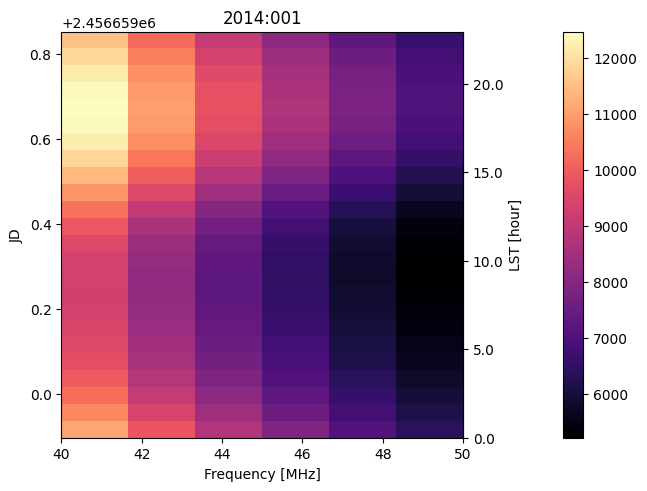

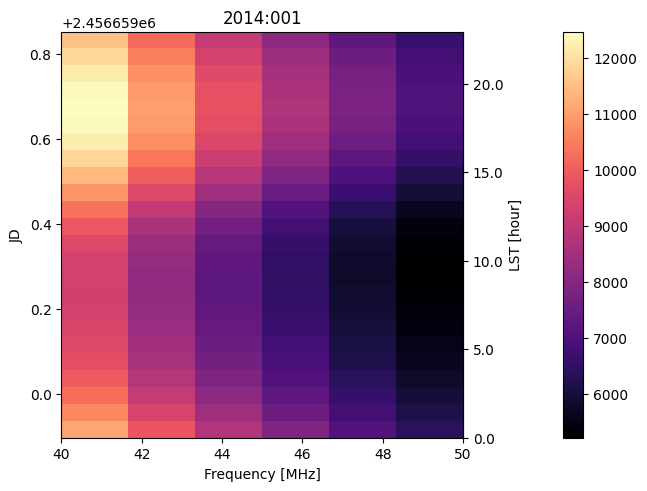

In [15]:
plots.plot_waterfall(spectra);

## Save the output

In [22]:
!rm results/simulated_spectra.gsh5
spectra.write_gsh5("results/simulated_spectra.gsh5");